In [1]:
import sys
from pyprojroot import here

sys.path.insert(0, str(here()))

import pandas as pd
import numpy as np
import xarray as xr

import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
import pymc_extras as pmx

from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve

from libpysal.weights import KNN, fuzzy_contiguity, w_union, W
import networkx as nx
import warnings

config = {
    'figure.figsize':(14,4),
    'figure.constrained_layout.use':True,
    'figure.facecolor':'w',
    'axes.grid':False,
    'grid.linewidth':0.5,
    'grid.linestyle':'--',
    'axes.spines.top':False,
    'axes.spines.bottom':False,
    'axes.spines.left':False,
    'axes.spines.right':False
}

plt.rcParams.update(config)


SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [2]:
from laos_gggi import load_shapefile
from laos_gggi.replication_data import create_replication_data
from laos_gggi.data_functions import load_emdat_data, load_all_data
from laos_gggi.sample import sample_or_load

# Event data

In [3]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [4]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

# Helper functions

In [5]:
def damage_plot(iso, idata, df = None, cls='hydro', group='posterior_predictive', var_name = 'y_hat'):
    fig, ax = plt.subplots()
    data = idata[group][var_name].sel(obs_iso=iso, obs_disaster_class=cls).groupby('obs_year').mean()
    if df is not None:
        targets = df.query('iso == @iso & disaster_class == @cls').groupby('year')['Total_Damage_Adjusted'].mean().resample('YS').last()
        ax.scatter(targets.index, targets.values, color='tab:red', zorder=100)
    mu = data.quantile(0.5, dim=['chain', 'draw']).to_dataframe()[var_name].resample('YS').last()

    hdi_80 = az.hdi(data, hdi_prob=0.8)[var_name].to_dataframe()[var_name].unstack('hdi').resample('YS').last()
    hdi_94 = az.hdi(data)[var_name].to_dataframe()[var_name].unstack('hdi').resample('YS').last()

   
    ax.scatter(mu.index, mu.values, s=70)

    ax.vlines(mu.index, *hdi_80.values.T, lw=3)
    ax.vlines(mu.index, *hdi_94.values.T)
    ax.grid(ls='--', lw=0.5)
    ax.set(title = f'{iso} - {cls}')
    plt.show()

In [6]:
def plot_predictions(idata, 
                     iso: str,
                     group: str = 'posterior_predictive',
                     var_name: str = 'y_hat',
                     obs_name: str | None = None,
                     data: pd.DataFrame | None = None,
                     **kwargs):
    if group not in ['prior', 'posterior', 'prior_predictive', 'posterior_predictive']:
        raise ValueError(f'Invalid group {group}')
    
    if obs_name and data is None:
        obs_df = idata.observed_data.sel(obs_iso=iso)[obs_name].to_dataframe()[obs_name].drop_duplicates().unstack('disaster')
    elif data is not None:
        obs_df = data.xs(level=0, key=iso)
        
    iso_idata = idata[group][var_name].sel(obs_iso = iso)
    mu = iso_idata.mean(dim=['chain', 'draw'])
    
    index = mu['obs_year'].values
    disasters = mu['disaster'].values
    
    fig, ax = plt.subplots(1, 2, **kwargs)
    
    for disaster, axis in zip(disasters, fig.axes):
        axis.plot(index, mu.sel(disaster=disaster).values, color='tab:blue')

        if obs_name:
            axis.plot(index, obs_df[disaster].values, color='k', marker='o')
    
        for hdi_prob in np.linspace(0.05, 0.95, 25)[::-1]:
            hdi = az.hdi(iso_idata.sel(disaster=disaster), hdi_prob=hdi_prob)[var_name]
            axis.fill_between(index, *hdi.values.T, color='tab:blue', alpha=0.1)
        axis.set(xlabel="Year", ylabel = "Disaster Count", title=f"{iso} {disaster.title()}")

    plt.show();
    

In [7]:
def ppc_plot(iso, classes, 
             idata=None,
             predictions=None,
             group='posterior', 
             target='y_hat',
             hdi_lim=1.0):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    
    if idata is None and predictions is None:
        raise ValueError('Need at least one of idata or predictions')
    
    for cls, axis in zip(classes, fig.axes):
        sel = {'obs_iso': iso, 'obs_disaster_class':cls}

        if predictions is None:
            pp = idata[f'{group}_predictive'].sel(obs_iso = iso)
        else:
            pp = predictions['predictions'].sel(obs_iso = iso)
        
        if cls not in pp.coords['obs_disaster_class']:
            axis.set_title(cls)
            continue
        else:
            pp = pp.sel(obs_disaster_class = cls)
        
        if idata is not None:
            obs = idata.observed_data.sel(obs_iso = iso)
            observed = True
        if cls not in obs.coords['obs_disaster_class']:
            obs = pp.copy().mean(dim=['chain', 'draw']) # Dummy data, otherwise plot_ppc throws a fit
            observed=False
        else:
            obs = obs.sel(obs_disaster_class = cls)
        
        pp[target] = pp[target] + np.random.uniform(0, 1e-6, size=pp[target].values.shape)
        
        az.plot_ppc(az.InferenceData(posterior_predictive=pp,
                                     observed_data=obs),
                    ax=axis,
                    var_names=target,
                    observed=observed,
                    legend=False)
            
        axis.set_title(cls)
        
        if hdi_lim < 1.0:
            hdi = az.hdi(pp, hdi_prob=hdi_lim)[target]
            higher = hdi.sel(hdi = 'higher').max()
            axis.set_xlim(0, higher)


## Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [8]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "square_ln_gdp_p", 
            "precip_deviation", 
            "co2", 
            "population"]

In [9]:
df.dropna(subset=features, inplace=True)

In [10]:
events_idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'year': 'obs_year', 'iso': 'obs_iso'} ), dim= "obs_idx" )

## Reconcile EMDAT and shapefile ISO codes

In [11]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world.index.unique()

In [12]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [13]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'SYC, LIE, STP, MNP, JEY, UNK, FRO, CYM, PCN, GGY, PRK, WLF, PLW, KNA, NIU, BHR, DMA, FLK, LUX, MHL, BLM, ATG, PRI, MLT, CPV, SMR, PSE, TTO, SHN, KIR, GRD, SGP, TON, MAC, TCA, SXM, AIA, COM, MDV, ASM, GUM, VCT, IOT, FSM, BMU, VEN, SPM, COK, GIB, SGS, NFK, CYP, BHS, BRB, MSR, CUW, VAT, GRL, TUV, JAM, MAF, ISR, IMN, VGB, QAT, AND, ABW, MCO, NRU, HMD, HKG, LCA, SLB, ATF, VIR'

In [14]:
# Drop codes not in both
common_codes = set(world_iso).intersection(set(df_iso))

df = df.query('iso in @common_codes').copy()
world = world.query('iso in @common_codes').copy()

In [15]:
# Get unique iso codes and years
code_idx, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)

In [16]:
y = df[disasters].copy().astype(float)

# Assume years without observed disasters had no disasters.
# **THIS IS A TERRIBLE ASSUMPTION **
# but sampling is too onerous without it.
y_filled = y.fillna(0)

# Damage data

In [17]:
emdat = load_emdat_data()

In [18]:
damage_events = (emdat['df_raw_filtered_adj']
           .loc[:, ['Start_Year', 'ISO', 'disaster_class', 'Total_Damage_Adjusted']]
           .dropna()
           .reset_index(drop=True)
           .rename(columns={'Start_Year':'year', 'ISO':'iso'}))

In [19]:
damage_events_full = (damage_events
     .groupby(['iso', 'year', 'disaster_class'])
     .apply(lambda x: x.assign(idx = np.arange(x.shape[0])), 
            include_groups=False)
     .reset_index()
     .set_index(['iso', 'year', 'disaster_class', 'idx']))

# Get unique iso codes and years
_, codes = pd.factorize(damage_events_full.index.get_level_values(0), sort=True)
_, years = pd.factorize(damage_events_full.index.get_level_values(1), sort=True)
_, classes = pd.factorize(damage_events_full.index.get_level_values(2))

power_set = pd.MultiIndex.from_product([codes, years, classes, [0]], names=['iso', 'year', 'disaster_class', 'idx'])
total = pd.MultiIndex.from_tuples(set(power_set.values).union(set(damage_events_full.index)), names=['iso', 'year', 'disaster_class', 'idx'])

damage_events_full = damage_events_full.reindex(total).sort_index().drop(columns=['level_3'])
df_damage_full = (pd.merge(damage_events_full.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage_full['Total_Damage_Adjusted'] = df_damage_full['Total_Damage_Adjusted'] / 1e6

In [20]:
df_damage = (pd.merge(damage_events.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage['Total_Damage_Adjusted'] = df_damage['Total_Damage_Adjusted'] / 1e6

In [21]:
df_damage_full = df_damage_full.query('iso in @df_damage.iso').copy()

In [22]:
# Get unique iso codes and years
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]
rename_dict = {col: f'obs_{col}' for col in idx_cols}

idx_damages = (xr.Coordinates
           .from_pandas_multiindex(df_damage.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))
idx_oos =(xr.Coordinates
           .from_pandas_multiindex(df_damage_full.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))

### Load predictions


In [23]:
# Add prediction data

# Load predictions
predictions = pd.read_csv(here("data/climate_forecast.csv")).rename(columns = {"time": "Start_Year"})
predictions['iso'] = 'LAO'
# Load IPCC data
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

# Create population density
predictions["population_density"] = predictions["Population"] / 236800 # Laos area in squared km hardcoded
predictions = predictions.rename(columns = {'Start_Year': 'year', 
                                            'Population': 'population',
                                              'dev_ocean_temp':'dev_from_trend_ocean_temp'})
predictions['year'] = pd.to_datetime(predictions['year'])

predictions['population'] = predictions['population'] / 1e6
predictions["real_gdp"] = predictions["real_gdp"] /  1e6


# Calculate logs
predictions["ln_population_density"] = np.log(predictions["population_density"])
predictions["ln_gdp_pc"] = np.log(predictions["real_gdp"])
predictions['square_ln_gdp_p'] = predictions["ln_gdp_pc"] **2

prediction_dates = [pd.to_datetime('2025-01-01 00:00:00'), 
         pd.to_datetime('2030-01-01 00:00:00'), 
         pd.to_datetime('2040-01-01 00:00:00'),
         pd.to_datetime('2050-01-01 00:00:00')]

shorter_pred = predictions.query('year in @prediction_dates').set_index(['iso', 'year' ] )

### Standardize data

In [24]:
# Damage features
damage_features_base = ['ln_population_density', 'ln_gdp_pc',
       'precip_deviation', 'co2', 'population']

damage_features_base_d = ['d_' + x for x in damage_features_base]
damage_features_base_d_stand = [x +"__standardized" for x in damage_features_base_d]

for x, d_x in zip(damage_features_base , damage_features_base_d):
    df_damage[d_x] = df_damage[x]

damage_features_d_stand = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'ln_gdp_pc__standardized_squared',
 'precip_deviation__standardized',
 'co2__standardized',
 'population__standardized',
 ]

# event features
features_events = ["ln_population_density", "ln_gdp_pc", 'square_ln_gdp_p', "precip_deviation", "co2", "population" ]


all_features = features_events + damage_features_d_stand + ['d_ln_gdp_pc__standardized_squared' ]

In [25]:
#Standardize dfs
from laos_gggi.statistics import standardize

transformer_events, df_stand = standardize(df = df, columns = features_events)
transformer_damages, df_damage_stand = standardize(df = df_damage, columns = features_events)


df_joint_stand = pd.DataFrame(transformer_damages.transform(df[features_events]),columns = damage_features_d_stand, index = df.index)

df_joint_stand =  df_joint_stand.join(df )

# Obtain ln_gdp_squared
df_joint_stand['ln_gdp_pc__standardized_squared'] = df_joint_stand['ln_gdp_pc__standardized'] **2



# Combine models

In [26]:
#Load idatas
damages_idata  = az.from_netcdf('idata/damages_model_4_v2.nc')
events_idata  = az.from_netcdf('idata/events_model_4_v2.nc')

damage_idata_2 = damages_idata.copy()


#Rename to avoid conflicts merging
events_idata = events_idata.rename({'latent_iso': 'latent_iso_events',
                                    })


damages_idata = damages_idata.rename({"country_loc": "country_loc_damage",
                                     'country_scale': 'country_scale_damage',
                                     'country_offset': 'country_offset_damage',
                                     'country_effect':'country_effect_damage',
                                      'beta': 'beta_damage',
                                      'beta_GY': 'beta_GY_damage',
                                      'mixture': 'mixture_damage',
                                      'alpha_X': 'alpha_X_damage',
                                      'latent_iso': 'latent_iso_damage',
                                      'phi': 'phi_damage',
                                      'phi_climatological_disasters': 'phi_climatological_disasters_damage',
                                      'phi_hydrological_disasters': 'phi_hydrological_disasters_damage',
                                      'rho': 'rho_damage',
                                      'sigma_X': 'sigma_X_damage',
                                      'theta': 'theta_Damage',
                                      'p_zero': 'p_zero_damage',
                                      'mu': 'mu_damage',
                                    })

#Merge posteriors
merged_posteriors_0 = xr.merge([damages_idata.posterior,
                              events_idata.posterior])

In [27]:
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]

In [28]:

# iso codes
code_idx, codes = pd.factorize(df.reset_index()['iso'], sort=True)
codes_to_idx = {name: idx for idx, name in enumerate(codes)}
codes_idx_joint=  df_joint_stand.reset_index()['iso'].map(codes_to_idx.get)

# class codes
class_idx, classes = pd.factorize(df_damage['disaster_class'].replace({'Hydrometereological': 'hydro', 
                                                                      'Climatological': 'climate'} ))
class_to_idx = {name: idx for idx, name in enumerate(classes)}

df_joint_stand['disaster_class'] = 'hydro'
class_idx_joint =  df_joint_stand['disaster_class'].map(class_to_idx.get)

# years
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)
year_to_idx = {name: idx for idx, name in enumerate(years)}
year_idx_joint =  df_joint_stand.index.get_level_values("year").map(year_to_idx.get)

national_features = list(filter(lambda x: x != 'co2__standardized', damage_features_d_stand))
world_features = ['co2__standardized']

training_years = [dt.year for dt in years]

coords_combined = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df_joint_stand.shape[0]),
    'features_events':features_events,
    'features_damages': damage_features_d_stand,
    'world_feature': world_features,
    'national_feature': national_features,
    'fixed_effect': ['iso', 'year'],
    'latent': ['iso', 'year'],
    'year_os' :  [ dt.year for dt in list(years) + prediction_dates]
}


# Combine coords
combined_xr_idx =( xr.Coordinates.from_pandas_multiindex(df_joint_stand.reset_index().set_index(['iso', 'year', 'disaster_class'])
                                                         .index.rename({'iso':'obs_iso', 
                                                                        'year':'obs_year',
                                                                        'disaster_class': 'obs_disaster_class'}), 'obs_idx'))


In [29]:
#Combined
with pm.Model(coords=coords_combined) as combined_model:
    ######################################## event model ########################################
    X_event = pm.Data('X', df_joint_stand[features_events])
    iso_idx_pt = pm.Data('iso_idx', codes_idx_joint, dims=['obs_idx'])

    latent_iso_events = pm.Flat('latent_iso_events', dims=['iso', 'features_events'])
    
    # Actual Model    
    country_loc = pm.Flat('country_loc', dims=['disaster'])
    country_scale = pm.Flat('country_scale',dims=['disaster'])
    country_offset = pm.Flat('country_offset', dims=['iso', 'disaster'])

    country_effect = pm.Deterministic('country_effect',
                                      country_loc[None] + country_scale[None] * country_offset, 
                                      dims=['iso', 'disaster'])
    
    
    # beta_sigma = 2.5 / df_joint[features_events].std().values[None] * df_joint_stand[disasters].std().values[:, None]
    beta = pm.Flat('beta', dims=['features_events', 'disaster'])
    beta_GY = pm.Flat('beta_GY', dims=['features_events', 'disaster'])    
    coef_effect = X_event @ beta + (latent_iso_events @ beta_GY)[iso_idx_pt]
    mixture = pm.Flat("mixture",
                               dims = ["iso", 'disaster'])

    latent_rate = (country_effect + mixture)[iso_idx_pt] + coef_effect
    mu = pt.softplus(latent_rate)
    
    zero_prob = pm.Flat('zero_prob',dims=['disaster'])
    alpha = pm.Flat('alpha',dims=['disaster'])
    
    y_hat_n_events = pm.ZeroInflatedNegativeBinomial('y_hat_n_events',
                                            psi=zero_prob,
                                            mu=pt.clip(mu, 1e-6, 300),
                                            alpha=alpha,
                                            observed = np.zeros((df_joint_stand.shape[0],2)),
                                            dims= ['obs_idx', 'disaster'])

    ######################################## event model ########################################
    X_damage = pm.Data('X_damage',   df_joint_stand[damage_features_d_stand], 
            dims=['obs_idx', 'features_damages'])
    
    co2_idx = damage_features_d_stand.index('co2__standardized')
    not_co2_idx = [i for i in range(len(damage_features_d_stand)) if i != co2_idx]
    
    # iso_idx_pt = pm.Data('iso_idx', codes_idx_joint, dims=['obs_idx'])
    year_idx_pt = pm.Data('year_idx', year_idx_joint, dims=['obs_idx'])
    class_idx_pt = pm.Data('class_idx', class_idx_joint, dims=['obs_idx'])

    
    latent_iso_damage = pm.Flat('latent_iso_damage', dims=['iso', 'features_damages'])
    latent_year_national = pm.Flat('latent_year_national',  dims=['year', 'national_feature'])
    latent_year = pt.zeros((len(years), len(damage_features_d_stand)))[:, not_co2_idx].set(latent_year_national)
    
    country_loc_damage = pm.Flat('country_loc_damage',  dims=['disaster'])
    country_scale_damage = pm.Flat('country_scale_damage', dims=['disaster'])
    country_offset_damage = pm.Flat('country_offset_damage', dims=['iso', 'disaster'])
    country_effect_damage = pm.Deterministic('country_effect_damage', 
                                             country_loc_damage + country_scale_damage * country_offset_damage,
                                      dims=['iso', 'disaster'])
    
    year_loc = pm.Flat('year_loc',dims=['disaster'])
    year_scale = pm.Flat('year_scale', dims=['disaster'])
    year_offset = pm.Flat('year_offset', dims=['year', 'disaster'])
    year_offset_new = pm.Normal( 'year_offset_new', 0, 1, dims=['year', 'disaster'])
    year_offset = pt.join(0, year_offset,  year_offset_new,  )
    year_effect = pm.Deterministic('year_effect', 
                                   year_loc[None] + year_scale[None] * year_offset, 
                                   dims=[ 'year_os', 'disaster'])

    
    
    beta_damage = pm.Flat('beta_damage', dims=['features_damages', 'disaster'])
    beta_GY_damage = pm.Flat('beta_GY_damage', dims=['fixed_effect', 'features_damages', 'disaster'])    
    coef_effect = (X_damage @ beta_damage + 
                   (latent_iso_damage @ beta_GY_damage[0])[iso_idx_pt] + 
                   (latent_year @ beta_GY_damage[1])[year_idx_pt] 
                  )
    mixture_damage = pm.Flat("mixture_damage",
                               dims = ["iso", 'disaster'])

    mu = (country_effect_damage + mixture_damage)[iso_idx_pt] + year_effect[year_idx_pt]  + coef_effect

    sigma = pm.Flat('sigma', dims=['disaster'])
    
    mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
    mu_damage = pm.Deterministic('mu_damage', pt.concatenate(mus, axis=0), dims=['obs_idx'])
    
    p_zero_damage = pm.Flat('p_zero_damage',dims=['disaster'])
    y_hat_damages = pm.HurdleLogNormal('y_hat_damages',
                   mu=mu_damage,
                   sigma= sigma[class_idx_pt],
                   psi=(1 - p_zero_damage)[class_idx_pt],
                   observed = np.zeros((df_joint_stand.shape[0],)) ,
                   dims=['obs_idx'])

    #################################### Damage curves ####################################
    damages_curves = pm.Deterministic("damages_curves", y_hat_damages * y_hat_n_events[: ,1], dims=['obs_idx'])

In [30]:
from pymc.model.transform.optimization import freeze_dims_and_data
with freeze_dims_and_data(combined_model ) :
    idata_post_combined = pm.sample_posterior_predictive(merged_posteriors_0 , extend_inferencedata=False, 
                                                      compile_kwargs={'mode':'JAX'},
                                                var_names=[ 'damages_curves', 'y_hat_damages', 'y_hat_n_events']
                                                       )

    idata_post_combined = idata_post_combined.assign_coords(combined_xr_idx)

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\link\jax\linker.py:27: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x13DCC773840>), RNG(<Generator(PCG64) at 0x13DCA92F680>), RNG(<Generator(PCG64) at 0x13DCC772B20>), RNG(<Generator(PCG64) at 0x13DCC5890E0>), RNG(<Generator(PCG64) at 0x13DCC7720A0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: sigma > 0) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
Sampling: [y_hat_damages, y_hat_n_events, year_offset_new]


Output()

In [72]:
idata_post_combined.posterior_predictive.damages_curves.sel(obs_iso='LAO',obs_year = pd.to_datetime('1990-01-01 00:00:00')).values.ravel()

array([0.        , 0.03495895, 0.        , ..., 0.        , 0.        ,
       0.        ])

In [75]:
from scipy import interpolate

computed_ry_damage = {}

for year in [ pd.to_datetime('1990-01-01 00:00:00'), 
                    pd.to_datetime('2000-01-01 00:00:00'), 
                    pd.to_datetime('2020-01-01 00:00:00'),]:
    
    damages = idata_post_combined.posterior_predictive.damages_curves.sel(obs_iso='LAO',obs_year = year).values.ravel()
    data = np.sort(damages)
    n = len(data)
    cdf_vals = np.linspace(1/n, 1, n)
    
    # Interpolate inverse CDF (PPF)
    ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
    
    def compute_ry_damage(ry):
        return ppf_func(1 - 1/ry)
    
    rys = np.array([5, 10, 25, 50, 100, 250, 500])
    computed_ry_damage[year.year] = compute_ry_damage(rys)

In [76]:
computed_ry_damage

{1990: array([0.00000000e+00, 6.52883733e-04, 3.79137898e-02, 1.43562953e-01,
        3.87396561e-01, 1.03743629e+00, 2.34661754e+00]),
 2000: array([0.        , 0.00342017, 0.03418896, 0.11230346, 0.27699739,
        0.68942302, 1.41664717]),
 2020: array([0.00000000e+00, 5.04102904e-03, 9.75153728e-02, 2.84711486e-01,
        7.97661646e-01, 2.80772116e+00, 5.48851110e+00])}

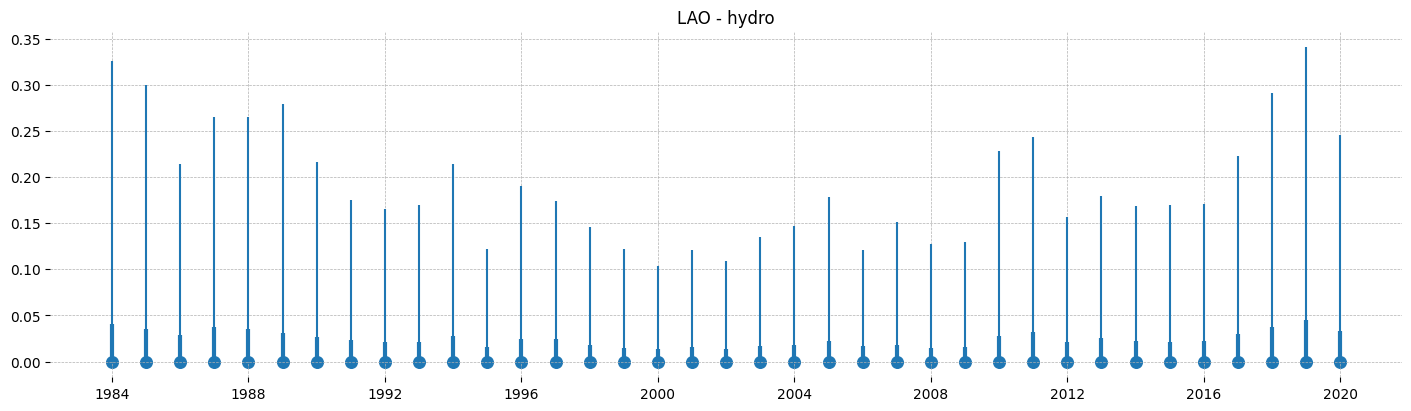

In [30]:
damage_plot( iso = 'LAO', idata= idata_post_combined, var_name= 'y_hat_damages' )

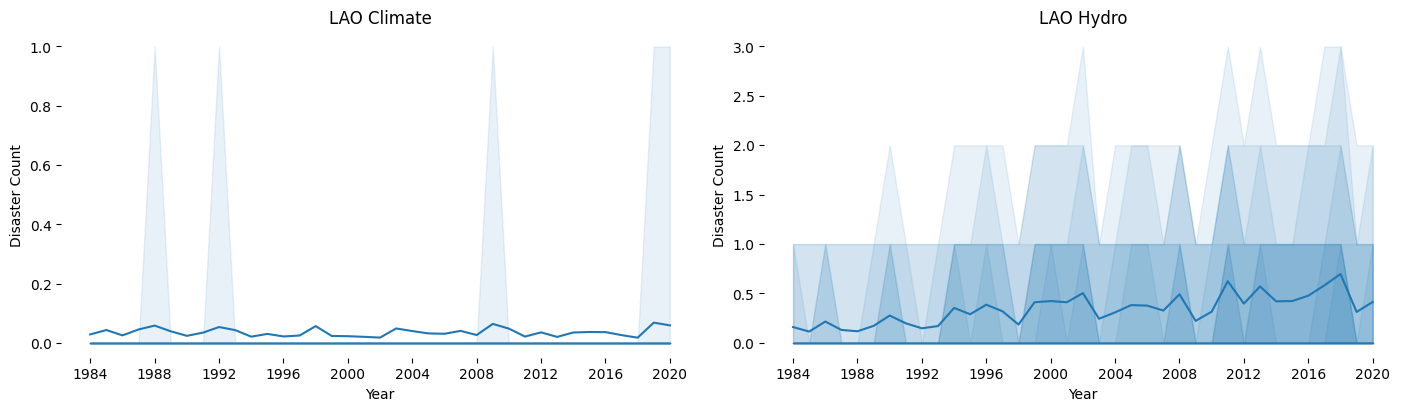

In [31]:
plot_predictions(idata_post_combined, 'LAO', 
                 'posterior_predictive',
                 obs_name= None, 
                 var_name= 'y_hat_n_events',
                 data= None)

# Flood walls

In [32]:
import os
from os.path import exists

import pathlib

import pytensor
from laos_gggi.model import add_data
from laos_gggi.plotting import configure_plot_style

from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data

In [33]:
# Set random seed
SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [58]:
# Configure pytensir floats
floatX = pytensor.config.floatX


# Load idatas
points_idata = az.from_netcdf(here('notebooks/geo_damage_model/model_closest_full_long.idata'))

#Rename to avoid conflicts merging
damage_idata_2 = damage_idata_2.rename({"country_loc": "country_loc_damage",
                                     'country_scale': 'country_scale_damage',
                                     'country_offset': 'country_offset_damage',
                                     'country_effect':'country_effect_damage',
                                      'beta': 'beta_damage',
                                      'beta_GY': 'beta_GY_damage',
                                      'mixture': 'mixture_damage',
                                      'alpha_X': 'alpha_X_damage',
                                      'latent_iso': 'latent_iso_damage',
                                      'phi': 'phi_damage',
                                      'phi_climatological_disasters': 'phi_climatological_disasters_damage',
                                      'phi_hydrological_disasters': 'phi_hydrological_disasters_damage',
                                      'rho': 'rho_damage',
                                      'sigma_X': 'sigma_X_damage',
                                      'theta': 'theta_Damage',
                                      'p_zero': 'p_zero_damage',
                                      'mu': 'mu_damage',
                                        'feature': 'feature_damage'
                                    })

#Merge posteriors
merged_posteriors = xr.merge([points_idata.sel(ISO = 'LAO').posterior,
                              damage_idata_2.sel(iso = 'LAO').posterior])

### Points data

In [59]:
grid_cols =  [ 'long', 'lat', 'distance_to_river', 'log_distance_to_river', 'log_distance_to_coastline', 'geometry', 'ISO',
'log_distance_to_river__standardized', 'log_distance_to_coastline__standardized' , 'log_distance_to_river__standardized__squared',
'log_distance_to_coastline__standardized__squared']

#Load event data sets
sea_point_grid = pd.read_csv(here("data/sea_point_grid.csv"),index_col=0  )[grid_cols]
laos_point_grid = pd.read_csv(here("data/laos_point_grid.csv"),index_col=0 )[grid_cols]
sea_df = pd.read_csv(here("data/sea.csv"),index_col=0 )
lao_df = pd.read_csv(here("data/lao.csv"),index_col=0 )
sea_df_stand = pd.read_csv(here("data/sea_df_stand.csv"),index_col=0 )
lao_df_stand = pd.read_csv(here("data/lao_df_stand.csv"),index_col=0 )

# Load damage df
damage_df_stand = pd.read_csv(here('data/df_damage_stand_2'),index_col =0 )
damage_df =  pd.read_csv(here('data/df_damage_2'),index_col =0 )

In [60]:
# create predictions_ISO
predictions["ISO"] = "LAO"

# Select years of interest
prediction_years = ["2026-01-01", "2030-01-01", "2040-01-01", "2050-01-01", "2070-01-01"]
predictions_short = predictions.query('Start_Year in @prediction_years')

# create grid point number
laos_point_grid = laos_point_grid.reset_index().rename(columns = {"index": "point_number" })

# merge grid and predictions
pred_df = pd.merge(laos_point_grid ,predictions_short, left_on= "ISO", right_on= "ISO", how = "left" )

# Create population density
pred_df["population_density"] = pred_df["Population"] / 236800 # Laos area in squared km hardcoded

# Calculate logs
pred_df["log_population_density"] = np.log(pred_df["population_density"])
pred_df["log_gdp_per_cap"] = np.log(pred_df["gdp_per_cap"])

In [61]:
# Define point features
point_features = ['lat', 'long', 'log_distance_to_river__standardized', "log_distance_to_coastline__standardized",
"log_distance_to_river__standardized__squared", "log_distance_to_coastline__standardized__squared",
 "Population__standardized", "co2__standardized", "precip_deviation__standardized", "dev_ocean_temp__standardized", 
'log_population_density__standardized','log_gdp_per_cap__standardized', 
"log_gdp_per_cap__standardized__squared", "log_population_density__standardized__squared" ]

distance_features = point_features[0:6]
time_varying_features = point_features[6:]
time_varying_features_base =[x[ :-14] for x in point_features[6:12]]

In [62]:
# Set damage features
name_converter =  {'ln_population_density': 'log_population_density',
                    'ln_gdp_pc': 'log_gdp_per_cap',
                    'precip_deviation': 'precip_deviation',
                    'co2': 'co2',
                    'population': 'Population'
                      
                   }

pred_df_damage = pred_df.copy()

damage_features_d = ["d_" + x for x in  damage_features_base]

damage_features_d_stand = [x + '__standardized' for x in damage_features_d]


for feature, d_feature in zip(damage_features_base,  damage_features_d ):
    pred_df[d_feature] = pred_df_damage[name_converter[feature]]
    damage_df[d_feature] = damage_df[feature]

### Standardize data

In [63]:
################## standardize points data ##################
from sklearn.preprocessing import StandardScaler as Standardize

# Select cols to stand
cols_to_stand = ['Population', 'dev_ocean_temp',
                 'co2', 'log_population_density', 'log_gdp_per_cap',
       'precip_deviation',]

cols_to_stand_stand = [x + "__standardized" for x in  cols_to_stand]

cols_not_stand = ['ISO' , 'Start_Year', 'lat', 'long', 'geometry', 'point_number', 'log_distance_to_river__standardized',
       'log_distance_to_coastline__standardized', 'log_distance_to_river__standardized__squared','log_distance_to_coastline__standardized__squared']


#Train transformers
transformer_stand_  =  Standardize().fit(sea_df[cols_to_stand] )

# standardize pred_df
pred_df_stand = transformer_stand_.transform(pred_df[cols_to_stand] )
pred_df_stand = pd.DataFrame(pred_df_stand, columns =cols_to_stand_stand )
pred_df_stand = pd.merge(pred_df_stand, pred_df[cols_not_stand], left_index=True, right_index= True, how = "left" )

In [64]:
################## standardize damage data ##################
# Select cols to stand
cols_to_stand_2 = damage_features_d.copy()

cols_to_stand_stand_2 = damage_features_d_stand.copy()

#Train transformers
transformer_stand__damage =  Standardize().fit(damage_df[cols_to_stand_2] )

# standardize pred_df
pred_df_stand_damage = transformer_stand__damage.transform(pred_df[cols_to_stand_2] )
pred_df_stand_damage = pd.DataFrame(pred_df_stand_damage, columns =cols_to_stand_stand_2 )
pred_df_stand = pd.merge(pred_df_stand, pred_df_stand_damage, left_index=True, right_index= True, how = "left" )

In [65]:
# Calculate logs squared
pred_df_stand["log_gdp_per_cap__standardized__squared"] = pred_df_stand["log_gdp_per_cap__standardized"] **2
pred_df_stand["log_population_density__standardized__squared"] = pred_df_stand["log_population_density__standardized"] **2
pred_df_stand["d_ln_gdp_pc__standardized_squared"] = pred_df_stand["d_ln_gdp_pc__standardized"] **2

### Center Laos lat-long using SEA data

In [66]:
# Compute sea center
sea_center =  {}

# center Laos values
for x in ["lat", "long"]:
    sea_center[x] = (sea_df[x].max() + sea_df[x].min()) /  2
    pred_df_stand[x + "_centered"] = pred_df_stand[x] - sea_center[x]

In [67]:
### Create pred_df_stand_dict for several years
pred_df_stand_dict = {}

pred_df_stand.loc[ : , 'Start_Year'] =  pd.to_datetime(pred_df_stand['Start_Year']).dt.year
pred_df_stand.loc[ : , 'Start_Year'] =pred_df_stand["Start_Year"].astype(int)

for year in pred_df_stand["Start_Year"].unique():
    pred_df_stand_dict[year] = pred_df_stand.query('Start_Year == @year')

# Set coords

In [68]:
# gp features
gp_features = ["lat", "long"]

# damage features
damage_features = ['d_ln_population_density__standardized',
 'd_ln_gdp_pc__standardized',
 'd_ln_gdp_pc__standardized_squared',
 'd_precip_deviation__standardized',
 'd_co2__standardized',
 'd_population__standardized']

# Event features
event_features = list(merged_posteriors.coords["feature"].values)

national_features = list(filter(lambda x: x != 'd_co2__standardized', damage_features))
world_features = ['d_co2__standardized']

In [69]:
# Define event coords
is_disaster_idx_events , is_disaster_events  = pd.factorize(sea_df_stand["is_disaster"])
ISO_idx_events , ISO_events  = pd.factorize(sea_df_stand["ISO"]) 
obs_idx_events  = sea_df_stand.index

# Define damage coords
ISO_idx_damage, ISO_damage =  pd.factorize(damage_df_stand["iso"])

# Prediction coords
obs_idx = pred_df_stand_dict[2026]["point_number"]


gp_features = ["lat", "long"]


# Rebuild ISO_idx_sea
ISO_idx, ISO = pd.factorize(sea_df["ISO"]) 

ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}
ISO_idx_laos =  pred_df_stand_dict[2026].ISO.map(ISO_to_idx.get)

years = pred_df_stand["Start_Year"].unique()

# ISO damage
ISO_damage_idx, ISO_damage =  pd.factorize(damage_df_stand["iso"])
ISO_to_idx_2 = {name: idx for idx, name in enumerate(ISO_damage)}
ISO_damage_idx_laos =  pred_df_stand_dict[2026].ISO.map(ISO_to_idx_2.get)

#


#Set coords_predictions
coords_predictions = {
    # "is_disaster" : is_disaster,
        "obs_idx": obs_idx,
        'iso_damages':ISO_damage, 
        "iso_points": ISO,
        "distance_features": distance_features,
        "time_varying_features" : time_varying_features,
        'event_features': event_features,
        "gp_feature":gp_features,
        "damage_features": damage_features,
        "year":years,
        'national_feature': national_features,
         'world_feature': world_features,
        'disaster': ['climate', 'hydro'],
         'fixed_effect': ['iso', 'year'],
        'year_os' : list(years) + ["2025", "2030",'2050']
                     }

# Compute the curves

In [70]:
# Compute center function
def compute_center(X):
    return (pt.max(X, axis=0) + pt.min(X, axis=0)).eval() / 2

In [71]:
from copy import deepcopy
from pymc.model.transform.optimization import freeze_dims_and_data

damage_curves_plot = {}
years = list(pred_df_stand_dict.keys())


for year in years:
    
    with pm.Model(coords=coords_predictions) as damage_curves_plot[year]:
        ####################################Events model####################################
        # Set data
        event_features_data = add_data(features= event_features ,  target = None, df =  pred_df_stand_dict[year],
                                   dims=['obs_idx', 'features'])
        X_gp = pm.Data("X_gp",  pred_df_stand_dict[year][["lat_centered", "long_centered"]].astype(floatX), dims=['obs_idx', 'gp_feature'])
    
        #Flat variables
        country_effect = pm.Flat("country_effect", dims = ["iso_points"])    
        beta = pm.Flat("beta", dims = ["event_features"])
        
        # HSGP component
        eta = pm.Flat("eta")
        ell = pm.Flat("ell", dims=["gp_feature"])
        cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)
    
        m0, m1, c = 35, 35, 1.5
        gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)
        gp._X_center = compute_center( pred_df_stand_dict[year][["lat_centered", "long_centered"]].values.astype(floatX))
    
        phi, sqrt_psd = gp.prior_linearized(X=X_gp)
    
        basis_coeffs = pm.Flat("basis_coeffs", size=gp.n_basis_vectors)
    
        HSGP_component = pm.Deterministic('HSGP_component', phi @ (basis_coeffs * sqrt_psd), dims=['obs_idx'])
    
        # Event model components
        event_features_component = pm.Deterministic('event_features_component', 
                                                    event_features_data @ beta, dims=['obs_idx'])

        event_features_component_inv_logit = pm.Deterministic('event_features_component_inv_logit', 
                                           pm.math.invlogit(event_features_component))

        HSGP_component_inv_logit = pm.Deterministic('HSGP_component_inv_logit', 
                                                   pm.math.invlogit(HSGP_component))
        
        logit_p = pm.Deterministic('logit_p', country_effect[ISO_idx_laos] + event_features_component 
                                   + HSGP_component, dims=['obs_idx'])
        event_prob_y_hat = pm.Deterministic('event_prob_y_hat', pm.math.invlogit(logit_p), dims=['obs_idx'])
    
        ###################################Damages model####################################
        X_damage = pm.Data('X_damage',  pred_df_stand_dict[year][damage_features], 
                dims=['obs_idx', 'features_damages'])
        
        co2_idx = damage_features.index('d_co2__standardized')
        not_co2_idx = [i for i in range(len(damage_features)) if i != co2_idx]
        
        # iso_idx_pt = pm.Data('iso_idx', codes_idx_joint, dims=['obs_idx'])
        year_idx_pt = pm.Data('year_idx', year_idx_joint, dims=['obs_idx'])
        class_idx_pt = pm.Data('class_idx', class_idx_joint, dims=['obs_idx'])
    
        
        latent_iso_damage = pm.Flat('latent_iso_damage', dims=['iso_damages', 'features_damages'])
        latent_year_national = pm.Flat('latent_year_national',  dims=['year', 'national_feature'])
        latent_year = pt.zeros((len(years), len(damage_features_d_stand)))[:, not_co2_idx].set(latent_year_national)
        
        country_loc_damage = pm.Flat('country_loc_damage',  dims=['disaster'])
        country_scale_damage = pm.Flat('country_scale_damage', dims=['disaster'])
        country_offset_damage = pm.Flat('country_offset_damage', dims=['iso_damages', 'disaster'])
        country_effect_damage = pm.Deterministic('country_effect_damage', 
                                                 country_loc_damage + country_scale_damage * country_offset_damage,
                                          dims=['iso_damages', 'disaster'])
        
        year_loc = pm.Flat('year_loc',dims=['disaster'])
        year_scale = pm.Flat('year_scale', dims=['disaster'])
        year_offset = pm.Flat('year_offset', dims=['year', 'disaster'])
        year_offset_new = pm.Normal( 'year_offset_new', 0, 1, dims=['year', 'disaster'])
        year_offset = pt.join(0, year_offset,  year_offset_new,  )
        year_effect = pm.Deterministic('year_effect', 
                                       year_loc[None] + year_scale[None] * year_offset, 
                                       dims=[ 'year_os', 'disaster'])
    
        
        
        beta_damage = pm.Flat('beta_damage', dims=['features_damages', 'disaster'])
        beta_GY_damage = pm.Flat('beta_GY_damage', dims=['fixed_effect', 'features_damages', 'disaster'])    
        coef_effect = (X_damage @ beta_damage + 
                       (latent_iso_damage @ beta_GY_damage[0])[iso_idx_pt] + 
                       (latent_year @ beta_GY_damage[1])[year_idx_pt] 
                      )
        mixture_damage = pm.Flat("mixture_damage",
                                   dims = ["iso_damages", 'disaster'])
    
        mu = (country_effect_damage + mixture_damage)[iso_idx_pt] + year_effect[year_idx_pt]  + coef_effect
    
        sigma = pm.Flat('sigma', dims=['disaster'])
        
        mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
        mu_damage = pm.Deterministic('mu_damage', pt.concatenate(mus, axis=0), dims=['obs_idx'])
        
        p_zero_damage = pm.Flat('p_zero_damage',dims=['disaster'])
        y_hat_damages = pm.HurdleLogNormal('y_hat_damages',
                       mu=mu_damage,
                       sigma= sigma[class_idx_pt],
                       psi=(1 - p_zero_damage)[class_idx_pt],
                       observed = np.zeros((df_joint_stand.shape[0],)) ,
                       dims=['obs_idx'])
    
        # # #################################### Damage curves ####################################
        damages_curves = pm.Deterministic("damages_curves", y_hat_damages * event_prob_y_hat, dims=['obs_idx'])

In [72]:
# Sample predictions
idata_plot_point = {}
for year in years:
    if exists(here(f"notebooks/geo_damage_model/damage_curves_floods_{year}.idata")):
        idata_plot_point[year] = az.from_netcdf(here(f"notebooks/geo_damage_model/damage_curves_floods_{year}.idata"))
                                                
    else:                                  
        with freeze_dims_and_data(damage_curves_plot[year] ):
            idata_plot_point[year] = pm.sample_posterior_predictive( merged_posteriors , extend_inferencedata=False, 
                                                              # compile_kwargs={'mode':'JAX'},
                                                        var_names=[
                                                                   "y_hat_damages"
                                                                  ])
            az.to_netcdf(data = idata_plot_point[year], filename= pathlib.Path(here(f"notebooks/geo_damage_model/damage_curves_floods_{year}.idata")))

TypeError: len() of unsized object